# GRM with PyMC — Item-specific K via grouped models

Real-world questionnaires often mix items with different numbers of response categories
(e.g., 3-point, 4-point, and 5-point scales in the same test).
Because `pm.OrderedLogistic` requires cutpoints of a fixed length,
we **group items by K** and fit one model per group.

## GRM via `pm.OrderedLogistic`

$$
P(u_{ij} > k \mid \theta_i, a_j, b_{jk}) = \sigma(\eta_{ij} - c_{jk})
$$

where

$$
\eta_{ij} = a_j \theta_i, \qquad c_{jk} = a_j b_{jk}
$$

Because $a_j > 0$ and $b_{j1} < \cdots < b_{j,K_j-1}$, the cutpoints $c_{jk}$ are automatically ordered.
This recovers the standard GRM: $P(u_{ij} \geq k) = \sigma(a_j(\theta_i - b_{jk}))$.

## Priors

$$
\theta_i \sim \mathcal{N}(0,1), \quad
a_j \sim \text{LogNormal}(0,0.5), \quad
b_{j1} \sim \mathcal{N}(0,1), \quad
\delta_{jk} \sim \text{HalfNormal}(1)
$$

with $b_{jk} = b_{j1} + \sum_{l=1}^{k-1}\delta_{jl}$ (cumsum reparameterization).

> **Note**: $\theta$ is estimated independently per group.
> Estimates are comparable in scale but not jointly constrained across groups.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az

## Data Generation

20 items with heterogeneous K:

| Group | K | Items |
|-------|---|-------|
| A | 3 | 0–6 (7 items) |
| B | 4 | 7–13 (7 items) |
| C | 5 | 14–19 (6 items) |

In [2]:
rng = np.random.default_rng(42)

N = 100  # respondents
J = 20   # items total

# K per item
K_per_item = np.array([3] * 7 + [4] * 7 + [5] * 6)

# True parameters
theta_true = rng.normal(0, 1, N)
a_true = rng.lognormal(0, 0.5, J)
# b_true[j]: sorted array of K_j-1 thresholds
b_true = [np.sort(rng.normal(0, 1, K_per_item[j] - 1)) for j in range(J)]

# Generate responses
Y = np.zeros((N, J), dtype=int)
for j in range(J):
    K_j = K_per_item[j]
    # P*(Y >= k) for k=1,...,K_j-1 — shape (N, K_j-1)
    eta = a_true[j] * (theta_true[:, None] - b_true[j][None, :])
    cum_p = 1 / (1 + np.exp(-eta))
    probs = np.concatenate([
        1 - cum_p[:, :1],
        cum_p[:, :-1] - cum_p[:, 1:],
        cum_p[:, -1:],
    ], axis=1)  # (N, K_j)
    u = rng.uniform(size=(N, 1))
    Y[:, j] = (u > np.cumsum(probs, axis=1)).sum(axis=1)

print(f"Response matrix shape: {Y.shape}")
for k in np.unique(K_per_item):
    items_k = np.where(K_per_item == k)[0]
    counts = np.bincount(Y[:, items_k].ravel(), minlength=k)
    print(f"K={k}: {len(items_k)} items, category counts = {counts}")

Response matrix shape: (100, 20)
K=3: 7 items, category counts = [275 154 271]
K=4: 7 items, category counts = [256  85 113 246]
K=5: 6 items, category counts = [193  38  92 124 153]


## Fit one model per K-group

Each model uses a **long-format** approach:
responses are stacked into a 1-D array and item/user indices select
the right parameters, allowing `pm.OrderedLogistic` to be called once per group
with item-specific `cutpoints[item_idx]`.

In [3]:
unique_K = sorted(np.unique(K_per_item))
idatas = {}
item_indices_by_k = {}

for k in unique_K:
    # Items in this group and their local indices (0, 1, ..., n_items_k-1)
    global_item_idx = np.where(K_per_item == k)[0]
    item_indices_by_k[k] = global_item_idx
    n_items_k = len(global_item_idx)

    # Flatten (N, n_items_k) response matrix to 1-D
    Y_k = Y[:, global_item_idx]  # (N, n_items_k)
    user_idx = np.repeat(np.arange(N), n_items_k)        # (N*n_items_k,)
    local_item_idx = np.tile(np.arange(n_items_k), N)    # (N*n_items_k,)
    obs = Y_k.ravel()                                     # (N*n_items_k,)

    with pm.Model() as model_k:
        theta = pm.Normal("theta", 0, 1, shape=N)
        a = pm.LogNormal("a", 0, 0.5, shape=n_items_k)

        # Ordered thresholds via cumsum: b shape (n_items_k, k-1)
        b_first = pm.Normal("b_first", 0, 1, shape=n_items_k)
        b_delta = pm.HalfNormal("b_delta", 1, shape=(n_items_k, k - 2))
        b = pm.Deterministic(
            "b",
            pt.concatenate(
                [b_first[:, None], b_first[:, None] + pt.cumsum(b_delta, axis=1)],
                axis=1,
            ),
        )  # (n_items_k, k-1), ordered per row

        # GRM cutpoints: c_{jk} = a_j * b_{jk} — shape (n_items_k, k-1)
        cutpoints = pm.Deterministic("cutpoints", a[:, None] * b)

        # Linear predictor per observation: eta = a_j * theta_i
        eta = a[local_item_idx] * theta[user_idx]  # (N*n_items_k,)

        # Single vectorised OrderedLogistic over all observations in this group
        pm.OrderedLogistic(
            "Y_obs",
            eta=eta,
            cutpoints=cutpoints[local_item_idx],  # (N*n_items_k, k-1)
            observed=obs,
        )

        idata = pm.sample(
            1000, tune=1000, chains=4,
            target_accept=0.9, random_seed=42,
        )

    idatas[k] = idata
    print(f"K={k} done")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, a, b_first, b_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
Initializing NUTS using jitter+adapt_diag...


K=3 done


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, a, b_first, b_delta]


...

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, a, b_first, b_delta]


Output()

/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/pytensor/tensor/subtensor.py:2486: RuntimeWarning: invalid value encountered in at
  np.add.at(x, idx, y)
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/pytensor/tensor/subtensor.py:2486: RuntimeWarning: invalid value encountered in at
  np.add.at(x, idx, y)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


K=5 done


## Results — Summary per group

In [4]:
for k in unique_K:
    print(f"\n=== K={k} ===")
    display(az.summary(idatas[k], var_names=["a", "b"], round_to=2))


=== K=3 ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],0.54,0.18,0.23,0.88,0.00,0.00,2797.82,2984.54,1.00
a[1],1.73,0.61,0.81,2.89,0.02,0.02,976.77,1145.29,1.01
a[2],0.74,0.27,0.32,1.27,0.01,0.00,2462.17,2820.31,1.00
a[3],1.44,0.31,0.89,2.00,0.01,0.01,1709.43,2241.46,1.00
a[4],0.92,0.31,0.41,1.48,0.01,0.01,2080.41,2754.87,1.00
a[5],0.71,0.18,0.38,1.06,0.00,0.00,2475.39,2767.89,1.00
a[6],0.61,0.18,0.29,0.93,0.00,0.00,2567.12,2980.38,1.00
"b[0, 0]",-0.40,0.41,-1.20,0.39,0.01,0.01,4021.42,2444.41,1.00
"b[0, 1]",0.37,0.44,-0.44,1.23,0.01,0.01,5800.57,2710.21,1.00
"b[1, 0]",0.19,0.18,-0.16,0.52,0.00,0.00,2446.47,2411.66,1.00



=== K=4 ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],1.08,0.31,0.54,1.65,0.01,0.01,1427.88,2198.30,1.0
a[1],2.02,0.69,0.92,3.30,0.02,0.02,1084.23,1443.97,1.0
a[2],0.56,0.14,0.32,0.85,0.00,0.00,1791.10,2940.09,1.0
a[3],0.90,0.23,0.49,1.31,0.01,0.00,1725.67,2322.36,1.0
a[4],0.83,0.20,0.47,1.21,0.00,0.00,1824.33,2591.18,1.0
a[5],0.59,0.19,0.25,0.94,0.00,0.00,2055.31,2785.29,1.0
a[6],0.53,0.14,0.27,0.77,0.00,0.00,2120.81,2888.38,1.0
"b[0, 0]",-1.10,0.33,-1.72,-0.53,0.01,0.01,1711.81,2446.10,1.0
"b[0, 1]",-0.48,0.26,-0.99,-0.03,0.00,0.00,2671.44,3034.00,1.0
"b[0, 2]",0.58,0.27,0.09,1.11,0.00,0.00,3135.15,3136.11,1.0



=== K=5 ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],0.80,0.22,0.42,1.21,0.01,0.00,1210.83,1692.88,1.01
a[1],0.97,0.21,0.61,1.36,0.01,0.00,1401.31,2078.97,1.00
a[2],1.24,0.30,0.73,1.82,0.01,0.01,1408.70,2127.02,1.00
a[3],0.66,0.19,0.34,1.03,0.01,0.00,1064.90,2250.95,1.01
a[4],1.66,0.45,0.92,2.53,0.02,0.01,852.41,1431.61,1.00
a[5],0.79,0.21,0.45,1.18,0.00,0.00,1791.22,2745.01,1.00
"b[0, 0]",-0.33,0.30,-0.90,0.23,0.01,0.01,2880.23,2547.61,1.00
"b[0, 1]",0.29,0.30,-0.25,0.85,0.00,0.01,3900.13,2825.34,1.00
"b[0, 2]",1.26,0.43,0.52,2.06,0.01,0.01,2265.88,2197.78,1.00
"b[0, 3]",2.12,0.59,1.14,3.24,0.02,0.01,1508.87,2218.41,1.00


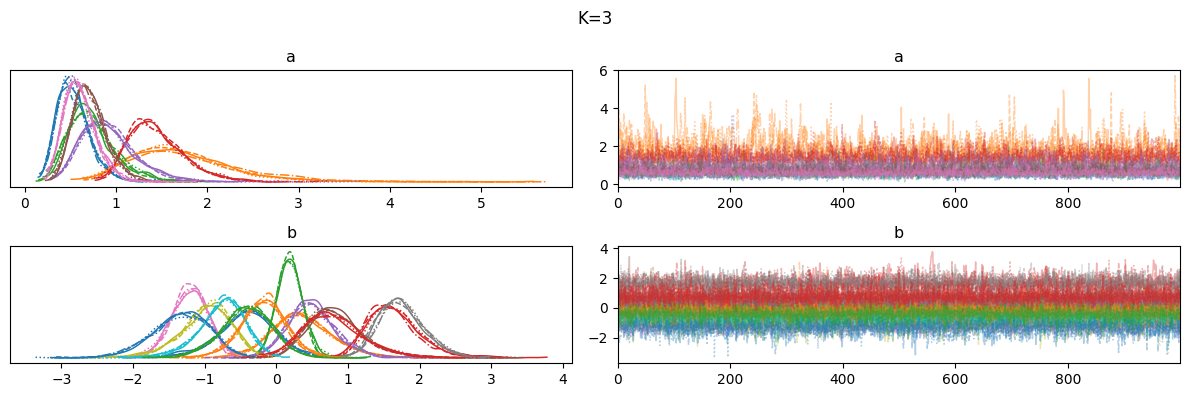

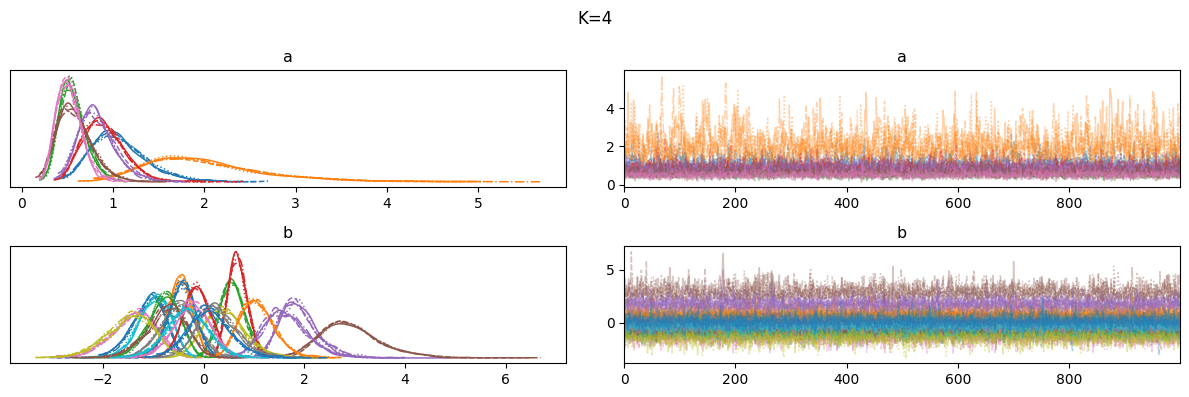

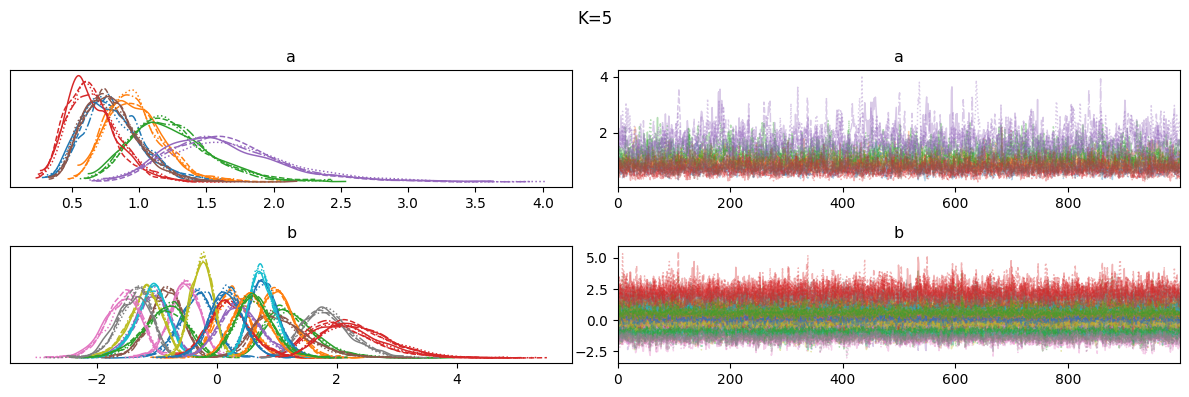

In [5]:
for k in unique_K:
    az.plot_trace(idatas[k], var_names=["a", "b"], compact=True)
    plt.suptitle(f"K={k}")
    plt.tight_layout()
    plt.show()

## Comparison: Estimated vs True Parameters

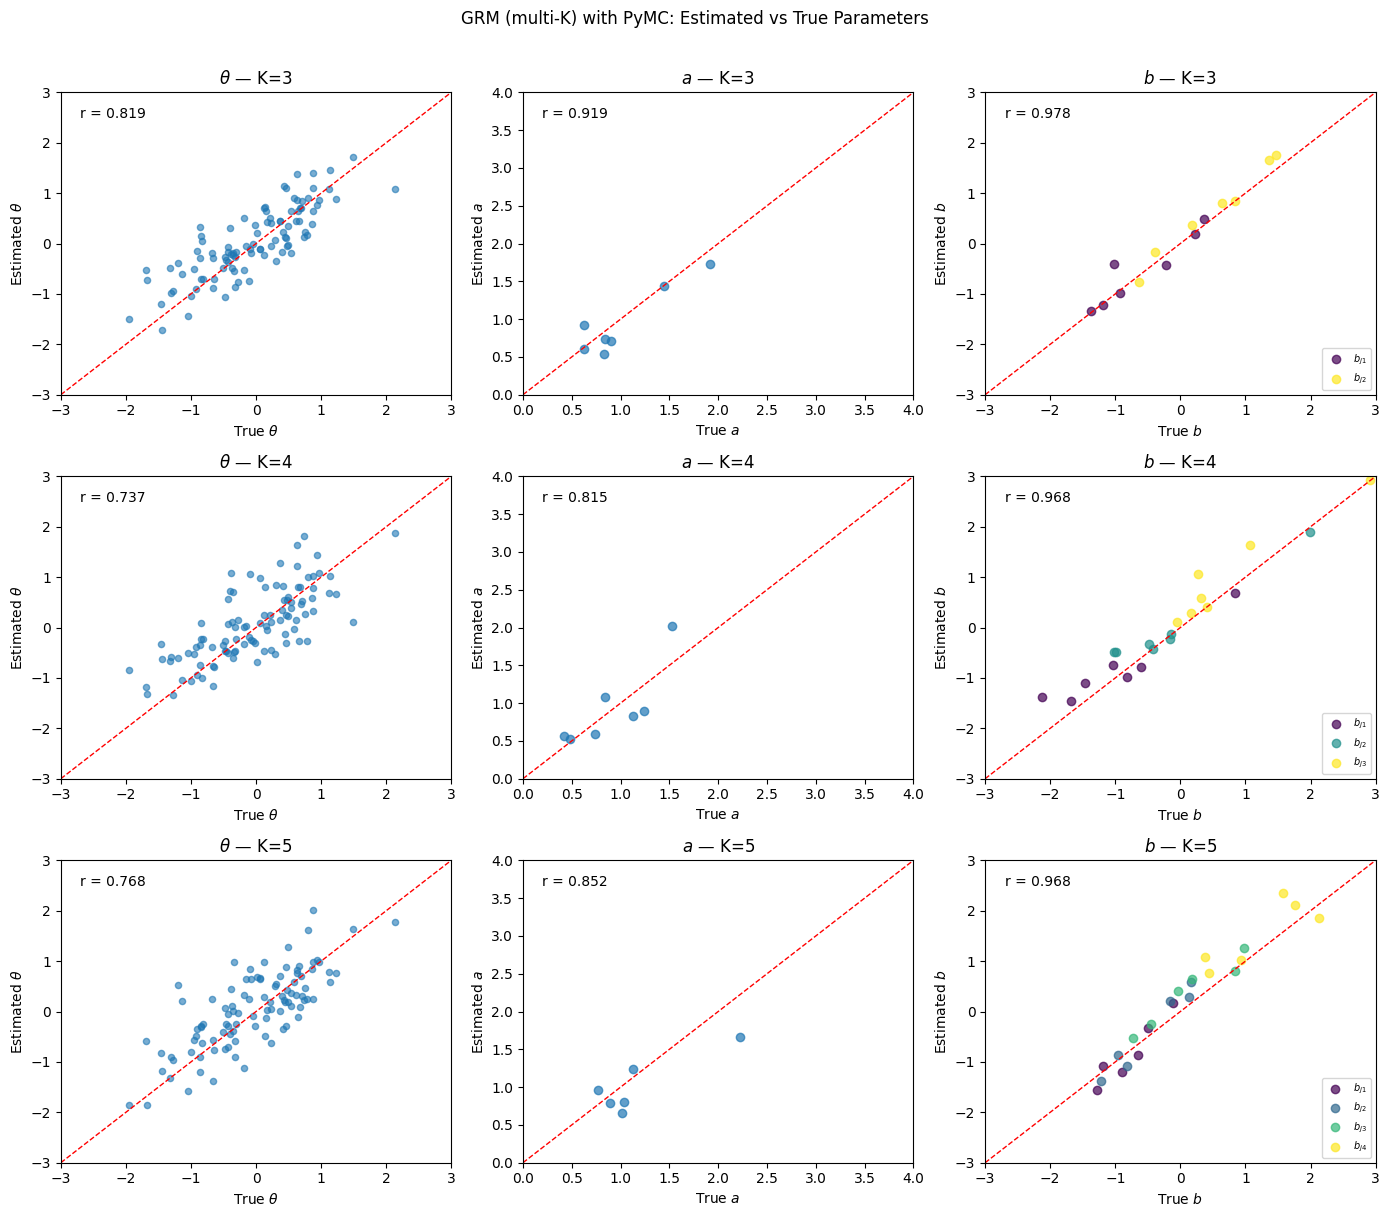

In [6]:
n_groups = len(unique_K)
fig, axes = plt.subplots(n_groups, 3, figsize=(14, 4 * n_groups))

for row, k in enumerate(unique_K):
    global_item_idx = item_indices_by_k[k]
    idata = idatas[k]

    theta_est = idata.posterior["theta"].mean(dim=["chain", "draw"]).values  # (N,)
    a_est = idata.posterior["a"].mean(dim=["chain", "draw"]).values           # (n_items_k,)
    b_est = idata.posterior["b"].mean(dim=["chain", "draw"]).values           # (n_items_k, k-1)

    a_true_k = a_true[global_item_idx]
    b_true_k = np.array([b_true[j] for j in global_item_idx])  # (n_items_k, k-1)

    # theta
    axes[row, 0].scatter(theta_true, theta_est, alpha=0.6, s=20)
    axes[row, 0].plot([-3, 3], [-3, 3], "r--", lw=1)
    axes[row, 0].set(xlim=(-3, 3), ylim=(-3, 3),
                     xlabel=r"True $\theta$", ylabel=r"Estimated $\theta$",
                     title=rf"$\theta$ — K={k}")
    r = np.corrcoef(theta_true, theta_est)[0, 1]
    axes[row, 0].text(0.05, 0.95, f"r = {r:.3f}", transform=axes[row, 0].transAxes, va="top")

    # a
    axes[row, 1].scatter(a_true_k, a_est, alpha=0.7)
    axes[row, 1].plot([0, 4], [0, 4], "r--", lw=1)
    axes[row, 1].set(xlim=(0, 4), ylim=(0, 4),
                     xlabel=r"True $a$", ylabel=r"Estimated $a$",
                     title=rf"$a$ — K={k}")
    r = np.corrcoef(a_true_k, a_est)[0, 1]
    axes[row, 1].text(0.05, 0.95, f"r = {r:.3f}", transform=axes[row, 1].transAxes, va="top")

    # b — all thresholds, colored by threshold index
    colors = plt.cm.viridis(np.linspace(0, 1, k - 1))
    for kk in range(k - 1):
        axes[row, 2].scatter(b_true_k[:, kk], b_est[:, kk],
                             alpha=0.7, color=colors[kk], label=f"$b_{{j{kk+1}}}$")
    axes[row, 2].plot([-3, 3], [-3, 3], "r--", lw=1)
    axes[row, 2].set(xlim=(-3, 3), ylim=(-3, 3),
                     xlabel=r"True $b$", ylabel=r"Estimated $b$",
                     title=rf"$b$ — K={k}")
    axes[row, 2].legend(fontsize=7)
    r = np.corrcoef(b_true_k.ravel(), b_est.ravel())[0, 1]
    axes[row, 2].text(0.05, 0.95, f"r = {r:.3f}", transform=axes[row, 2].transAxes, va="top")

plt.suptitle("GRM (multi-K) with PyMC: Estimated vs True Parameters", y=1.01)
plt.tight_layout()
plt.show()